# Transcription Circuits

In this lecture we cover:
- circuit principles
- mathematical models to describe genetic circuits

In [8]:
import numpy as np
import matplotlib.pyplot as plt

## Circuits

We may view a pathway as a system that comprises of:
- a set of input species
- a set of output species
- a set of internal species
- a set of reactions that describe the interactions among all these species

An example is shown below where `lacI` represses expression of `lacZ` as indicated via the arrow head `-|`.

<figure style="width: 70%; margin: auto; padding: 20px; background-color:white;">
  <img src="figs/lacI_to_lacZ.jpeg" alt="LacI to LacZ pathway">
  <figcaption><b>Fig:</b> Example pathway: LacI repressor controlling LacZ expression.</figcaption>
</figure>

This is very similar to what is called a _circuit_ which comprises of:
- a set of input ports/nodes
- a set of output ports/nodes
- a set of internal nodes
- a set of electronic components that relate signals at the nodes to each other.

We will thus refer to a pathway as a _biological circuit_.
There are _natural_ circuits that have naturally evolved and _synthetic_ biological circuits that have been engineered into the cell.
Synthetic circuits, however, use components of naturally evolved circuits that are then either used directly or adapted for synthetic circuits.

### Signals
An _execution_ or _signal trace_ of an electronic circuit is given by the voltage $u(t)$ at each of its nodes
with respect to a ground potential over time $t$.
An execution not only depends on the circuit, but also on the circuit _environment_, interacting with the circuit via its input and output ports - in the end we want the circuit to react differently to different inputs.

A digital signal with values in $\{0,1\}$ is sometimes more convenient when designing, analyzing, and simulating a circuit and it is obtained from the analog signal by discretizing at a _threshold voltage_.

> **_Side note._**  In some contexts more than two discrete signal values are used. One such example is using 0 and 1 for strong signal values and $X$ for an intermediate signal value. This becomes relevant when signals spend a significant amount of time within value-ranges that are neither clear 0 nor 1.
> One can also compute with such an extended logic [(Friedrichs, Függer, Lenzen, IEEE Transactions on Computers 2018)](https://ieeexplore.ieee.org/abstract/document/8314764).

Signals in a biological circuit are typically given as concentrations or counts (in a fixed volume) of species over time.
We will see that digital abstractions will also be used in biological circuits.

However, we stress that signals are not necessarily voltages and concentrations.
For example, in electrical circuits, it is sometimes more convenient to use the current $i(t)$ through a certain connection between nodes as the signal.
We may even mix signal domains and use current for the input signal and voltage for the output signal or vice versa.
Likewise, current-analogs are used in biological circuits as signals.
Examples are production rates of species
[(Aoki, Lillacci, Gupta, Baumschlager, Schweingruber, Khammash,  Nature 2019)](https://www.nature.com/articles/s41586-019-1321-1)
and the number of RNA polymerases (RNAPs) that pass a certain DNA bp per time (RNAP flux)
[(Kelly et al., J. of Biological Engineering 2009)](https://jbioleng.biomedcentral.com/articles/10.1186/1754-1611-3-4),
[(Espah Borujeni, Zhang, Doosthosseini, Nielsen, Voigt, Nature comm. 2020)](https://www.nature.com/articles/s41467-020-18630-2).




### Circuit components
Examples for analog electronic components are the resistor and the capacitor,
example for digital components (gates) are the inverter (INV), a NAND gate, and a NOR gate:

<figure style="width: 100%; margin: auto; padding: 20px; background-color:white;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/c/cb/Circuit_elements.svg" alt="electronic components">
  <figcaption><b>Fig:</b> Electronic circuit components (from wikimedia, https://upload.wikimedia.org/wikipedia/commons/c/cb/Circuit_elements.svg)</figcaption>
</figure>

Let us start with two analog components.
The _resistor_ with resistance $R$ between two of the circuit's nodes $p$ and $q$ relates voltage $u_{pq}(t)$ and
current $i_{pq}(t)$ accross it by
$$
u_{pq}(t) = R \cdot i_{pq}(t) \enspace.
$$

The _capacitor_ with capacitance $C$ relates voltage $u_{pq}(t)$ and current $i_{pq}(t)$ across it by
$$
i_{pq}(t) = C \cdot \frac{du_{pq}(t)}{dt} \enspace.
$$

These analog components do not have dedicated input and output ports.
They are undirected and simply restrict signals among the ports they connect in certain ways.

Thus, a priori, such a circuit thus does not have a direction.
The choice of which ports are inputs and which ones outputs is irrelevant for the executions it produces.
It is rather a convention to tell the circuit's user which node voltages we propose to vary (via the environment) to obtain a certain intended behavior at the output nodes (given that the output's environment does not interfere with this).

Additionally to the circuit components, we also need to include the _Kirchhoff current law_.
Let $p$ be a node in the circuit and $N(p)$ the set of neighboring nodes. Then,
$$
\sum_{q \in N(p)} i_{qp}(t) = 0\enspace.
$$
Further, the _Kirchhoff voltage law_ states that along a closed path $C$ of edges
in the circuit,
$$
\sum_{e \in C} u_{e}(t) = 0\enspace.
$$

### Charging a capacitance

Let's look at a small example, an RC circuit, shown in the figure below where a capacitance C is charged via a resistance R.

<figure style="width: 100%; margin: auto; padding: 20px; background-color:white;">
  <img src="figs/circuit_RC.svg" alt="RC cricuit">
  <figcaption><b>Fig:</b> RC circuit</figcaption>
</figure>

We have marked the ground potential with $0\,\text{V}$, a dedicated input node and an output node.
Input and output signals are in terms of voltage.

The first assumption made is one about the _circuit's environment_: we have assumed that the output current is $0$A. While this may be true for some circuits, or at least approximately hold since output currents are very low, it may be violated for others.
For example, we cannot simply compose two such circuits sequentially: the assumption would most a priori be violated with a positive input current of the second instance.

For the input environment, we assume that the input voltage was $0$ V all before time $0$, and has jumped to
$1$ V at time $0$ where it remains.

We have:
\begin{align}
u_R(t)    &= R \cdot i_R(t)       \qquad&&\text{(resistor rule)}\\
i_C(t)    &= C \cdot \frac{du_{out}(t)}{dt}       \qquad&&\text{(capacitor rule)}\\
u_{in}(t) &= u_R(t) + u_{out}(t)        &&\text{(Kirchhoff voltage)}\\
i_{R}(t) &= i_C(t)        &&\text{(Kirchhoff current)}\\
\end{align}

and thus

\begin{align}
\frac{du_{out}(t)}{dt}   &= \frac{1}{RC} \left( u_{in}(t) -  u_{out}(t) \right)&& \\
u_{out}(0) &= 0  &&\text{(input environment)}
\end{align}

The change of the output $\frac{du_{out}(t)}{dt}$ is thus proportional to the difference of input and output $u_{in}(t) -  u_{out}(t)$.
If $u_{in}(t) > u_{out}(t)$, the output is corrected to increase and vice versa for $u_{in}(t) < u_{out}(t)$.

For our assumptions of an input at $1$ V, we observe that the following equation fulfills the above differential equation and initial conditions
\begin{align}
u_{out}(t) =  1 - e^{-\frac{t}{RC}} \enspace.
\end{align}
Let's plot it over time:

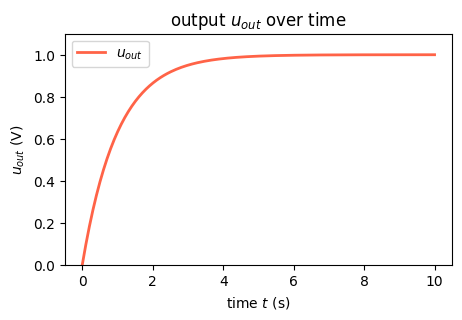

In [9]:
# compute
t = np.linspace(0, 10, 200)
R = 1
C = 1
uout = 1 - np.exp(-t/(R*C))

# build plot
plt.figure(figsize=(5,3))
plt.title('output $u_{out}$ over time')
plt.xlabel("time $t$ (s)")
plt.ylabel("$u_{out}$ (V)")
plt.plot(t, uout, linewidth=2, color="tomato", label="$u_{out}$")
plt.ylim(0,1.1)
plt.legend()
plt.show()

The plot clearly shows how the capacitance is charged over time until it reaches a limit.

## Gene expression model

Let's turn to biological circuits.
We will start by thinking about a single gene, coding for a single corresponding protein. This minimal example will allow us to develop intuition for the dynamics of the simplest gene regulations systems and lay out a procedure that we can further extend to analyze more complex circuits. 

What protein concentration will be produced by a gene *x*? We assume that the gene will be transcribed to mRNA and those mRNA molecules will in turn be translated to produce proteins, such that new proteins are produced at a total rate $\beta$ molecules per unit time. The $x$ protein does not simply accumulate over time. It is also removed both through active degradation as well as dilution as cells grow and divide. For simplicity, we will assume that both processes tend to reduce protein concentrations through a simple first-order process, with a rate constant $\gamma$. 

Thus, we can draw a diagram of our simple gene, x, with its protein being produced and removed (dashed circle):


<figure style="width: 80%; margin: auto; padding: 20px; background-color:white;">
  <img src="figs/expression.svg" alt="expression of a gene">
</figure>

<br>

> **_Side note (glyphs):_** We are using the standard [SBOL visual glyphs](https://sbolstandard.org/visual-glyphs/) to draw such figures. 

Here, protein production occurs at rate $\beta$ and degradation+dilution at rate $\gamma x$. We can then write down a simple ordinary differential equation (ODE) describing these dynamics:

\begin{align} 
&\frac{dx}{dt} = \mathrm{production - (degradation+dilution)} \\[1em]
&\frac{dx}{dt} = \beta - \gamma x
\end{align}

where 

\begin{align}
\gamma = \gamma_\mathrm{dilution} + \gamma_\mathrm{degradation}
\end{align}

Luckily this ODE falls into a simple class of ODEs with known solutions: so-called linear ODEs.
Indeed we encountered them in the ODE preliminary chapter and know that its solution is:

\begin{align}
x(t) = x_\mathrm{st} + (x_0 - x_\mathrm{st})\, e^{-\gamma t}, \qquad x_\mathrm{st} = \frac{\beta}{\gamma},
\end{align}

where $x_0 = x(0)$ is the initial protein concentration. For the special case $x(0) = 0$ of no initial presence of protein, this simplifies to

\begin{align}
x(t) = \frac{\beta}{\gamma}\!\left(1 - e^{-\gamma t}\right).
\end{align}

The concentration rises exponentially toward the steady state $x_\mathrm{st} = \beta/\gamma$ with time constant $\tau = 1/\gamma$. Note the direct analogy to the RC circuit: $x_\mathrm{st}$ plays the role of $u_{in}$ and $1/\gamma$ plays the role of $RC$.

> **_Side note (arrows in the diagram):_** The arrows resemble chemical reaction arrows. That is intended as we will later see. Precisely there are two type of arrows/reactions that we did not distinguish in the picture. The first one generates something and the second one transforms something into something. In the picture is clear what is what, but when we will use these reactions to describe systems we need to be clear. 

> **_Side note (units):_** What are the units of $x$, $\beta$, and $\gamma$? Try to find out yourself by starting with $x$ before reading on. For $x$ there is actually a choice to make. We, and most, hinted here that $x$ is a concentration (expected number for a fixed volume would be an alternative choice for probabilistic systems). We would then eed to decide which concentration we go for: numbers per volume ($1/m^3$), molar ($mol/m^3$), mass per volume ($g/m^3$), etc. While all of these make sense in different contexts, a natural choice for proteins in a small volume is numbers per volume since this number may be linked to experimental results most directly.
From there on we deduce $[x] = m^{-3}$, $[dx/dt] = m^{-3}s^{-1}$, and thus for rate constants $[\beta] = m^{-3}s^{-1}$ and $[\gamma][x] = [dx/dt]$ and thus $[\gamma] = s^{-1}$. Often we will use non-SI units like $uL^{-1}$ or $min^{-1}$, again since they can be directly linked to experimental outcomes.

> **_Side note (effective degradation rates):_**  When cells are growing, protein is removed through both degradation and dilution. For stable proteins, dilution dominates. For very unstable proteins, whose half-life is much smaller than the cell cycle period, dilution may be negligible. In bacteria, mRNA half-lives (1-10 min, typically) are much shorter than protein half-lives. In eukaryotic cells this is not necessarily true (mRNA half-lives can be many hours in mammalian cells).

> **_Side note (systematic ODEs):_**  For the eletronic circuit the ODEs were obtained systematically. Not so for the biocircuit. We will later discuss how to obtain the ODEs in a systematic way. In short outlook on this is given in the next section.

## Systematic model and simulation

We created an ODE that describes the transient behavior of the our first simple circuit. ODEs are great for modeling such dynamical systems, from very simple ones like this where we choose ODEs by hand to complex system behavior. Like every model, ODEs have limitations that we will discuss later.

> **_Question (limitations):_** Can you think of some?

Indeed there are systematic ways to derive the ODEs from more abstract system descriptions like bio-chemical reactions (a concept borrowed from chemistry). We have a full lecture on this, so only some basic principles here.

The figure showed 2 reactions as arrows:

\begin{align} 
\emptyset &\rightarrow X\\[1em]
X &\rightarrow \emptyset
\end{align}

where $\emptyset$ is short for ``nothing``.
It also specified some rates for these reactions. Since these are of some often used standard form that we will discuss in the upcoming lecture, it is enough to just state the constants $\beta$ and $\gamma$ instead of the complete rates $\beta$ and $\gamma X$. To distinguish them from the reaction rates, they are called _reaction rate constants_.

Using a library like [MobsPy](https://github.com/ROBACON/mobspy), we can now simply simulate the transient via:

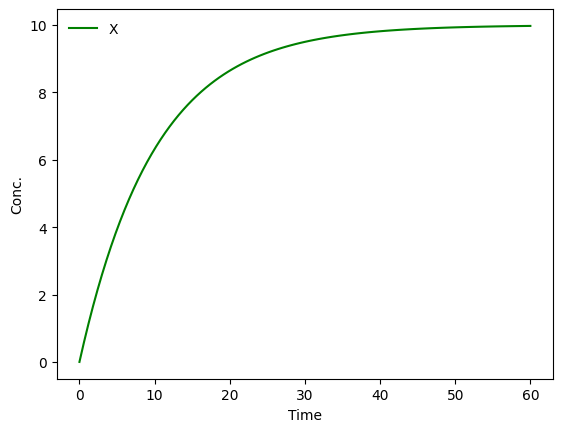

In [10]:
# uncomment for installing:
# %pip install mobspy

import mobspy as mp

X = mp.BaseSpecies()

# parameters
volume = 1.0
beta = 1.0
gamma = 0.1

# production
mp.Zero >> X [beta]

# degradation & dilution
X >> mp.Zero [gamma]

# simulate
MySim = mp.Simulation(X)
MySim.run()

While for quick prototyping unitless simulations can be nice, let's stick to units as we derived them just before. We also set the volume of the cell to a typical volume of an _E. coli_.

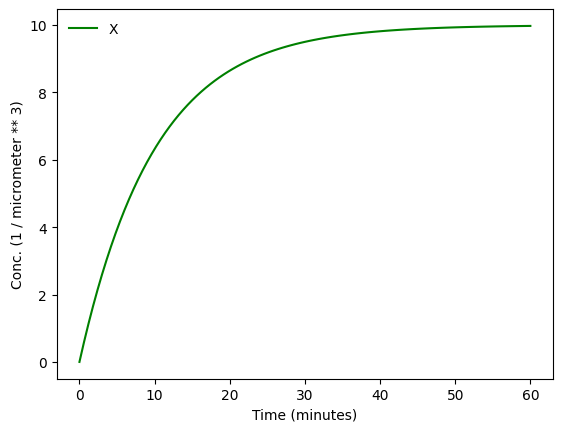

In [11]:
# E. coli volume
volume = 1.0 * mp.u("um**3")

# protein species
X = mp.BaseSpecies()

# parameters
beta = 1.0 / mp.u.min / volume
gamma = 0.1 / mp.u.min

# production
mp.Zero >> X [beta]

# degradation & dilution
X >> mp.Zero [gamma]

# simulate
MySim = mp.Simulation(X)
MySim.run(duration=60 * mp.u.min, volume=volume, unit_y = 1 / volume)

## Relation to electronic circuits

Let's for a moment stop and again look at the equation of the RC circuit for the case $u_{in}(t) = c$ for $t \geq 0$.
Both equations look deceptively similar:

\begin{align}
\frac{du_{out}(t)}{dt}   &=  \frac{c}{RC} -  \frac{1}{RC} \cdot u_{out}(t) && \text{ (RC circuit)}\\
\frac{dx}{dt} &= \beta - \gamma x && \text{ (gene regulation)}
\end{align}

In fact the electronic circuit behaves the same as the genetic circuit if $\beta = \frac{c}{RC}$ and $\gamma = \frac{1}{RC}$; a strange coincidence?

While a relation between the circuits is not immediate, let's consider a different, slightly adapted, electronic circuit shown below.

<figure style="width: 100%; margin: auto; padding: 20px; background-color:white;">
  <img src="figs/circuit_RC_v2.svg" alt="RC cricuit (v2)">
  <figcaption><b>Fig:</b> RC circuit (v2)</figcaption>
</figure>

Now the _input signal_ is the input current $i_{in}(t)$ and the output signal the output voltage $u_{out}(t)$; at least for the moment.

We have,
\begin{align}
i_C(t) &= C \cdot \frac{du_{out}(t)}{dt} &&\text{ (capacitor rule)}\\
i_R(t) &= \frac{1}{R} \cdot u_{out}(t) &&\text{ (resistor rule)}\\
i_{in}(t) &= i_C(t) + i_R(t) && \text{ (Kirchhoff current)}
\end{align}

and thus
\begin{align}
C \cdot \frac{du_{out}(t)}{dt} &= i_{in}(t) - \frac{1}{R} \cdot u_{out}(t)
\end{align}

Let us change the output even further to the charge $Q(t)$ that is stored in the capacitor at time $t$.
For a capacitor with voltage $u(t)$ across it, it holds that
$$
Q(t) = C \cdot u(t) \enspace.
$$

Calling the output signal $Q_{out}$, we thus have,
\begin{align}
\frac{dQ_{out}(t)}{dt} &= i_{in}(t) - \frac{1}{RC} \cdot Q_{out}(t) \enspace.
\end{align}

Let's compare: the _input current_ $i_{in}$ now corresponds to the production rate $\beta$,
the _output charge_ $Q_{out}$ to the protein counts (per volume), and
$\frac{1}{RC}$ to the degradation and dilution rate $\gamma$.

> **_Question:_** Can you intuitively explain the relation between both the electronic and the genetic circuit? What is the unit of $i_{in}$ as an SI unit, and what is it in terms of charge $Q$? What is the unit of $\beta$?




## Solving for the steady state

Often, one of the first things we would like to know is the concentration of protein under steady state conditions. To obtain this, we set the time derivative to 0, and solve:

\begin{align}
              &\frac{dx}{dt} = \beta - \gamma x = 0 \\[1em]
\Rightarrow \,&x_{\mathrm{st}} = \beta / \gamma 
\end{align}

In other words, the steady-state protein concentration depends on the ratio of production rate to degradation rate.

## Refined expression model

This description does not distinguish between transcription and translation. However, considering both processes separately can be important in more dynamic and stochastic contexts that we will encounter later in the course. To do so, we can simply add an additional variable to represent the mRNA concentration, which is now transcribed, translated to protein, and degraded (and diluted), as shown schematically here:

<figure style="width: 550px; margin: auto; padding: 20px; background-color:white;">
  <img src="figs/transcription_translation.svg" alt="transcript_and_translation">
</figure>

These reactions can be described by two coupled differential equations for the mRNA (m) and protein (x):

\begin{align}
&\frac{dm}{dt} = \beta_m - \gamma_m m, \\[1em]
&\frac{dx}{dt} = \beta_p m - \gamma_p x. 
\end{align}

Now, we can  determine the steady state mRNA $m_\mathrm{st}$ and protein $x_\mathrm{st}$ concentrations straightforwardly, by setting both time derivatives to 0 and solving. We find:

\begin{align}
&m_\mathrm{st} = \beta_m / \gamma_m, \\[1em]
&x_\mathrm{st} = \frac{\beta_p m_\mathrm{st}}{\gamma_p} = \frac{\beta_p \beta_m}{\gamma_p \gamma_m}.
\end{align}

From this, we see that the steady state protein concentration is proportional to the product of the two synthesis rates and inversely proportional to the product of the two degradation rates. 

And this gives us our first design rule:

> **_Design rule:_**  the cell can control protein expression level in at least **four different ways:** It could modulate (1) transcription, (2) translation, (3) mRNA degradation or (4) protein degradation rates. Or combinations thereof.

> **_Question:_** Are there tradeoffs between these different options? Are they all used indiscriminately or is one favored in natural contexts? 

## Transcription regulation

Life would be simple—perhaps too simple—if genes were simply left on all the time. To make things interesting the cell has to regulate them, turning their expression levels lower or higher depending on environmental conditions and other inputs. One of the simplest ways to do this is through repressors.
Repressors are proteins that can bind to **operators** that are specific binding sites at or near a promoter to change its activity.
Often the strength of their binding is contingent on external inputs. For example, the `LacI` repressor normally turns off the genes for lactose utilization in *E. coli*.
However, in the presence of lactose in the media, a modified form of lactose binds to `LacI`, inhibiting its ability to repress its target genes. Thus, a nutrient (lactose) can regulate expression of genes that allow the cell to use it. 

In the following diagram, we label the repressor $R$, the unoccupied operator $O$, and the occupied operator $O_{occ}$.

<figure style="width: 550px; margin: auto; padding: 20px; background-color:white;">
  <img src="figs/repression.svg" alt="Repression of a gene via binding of R at operator site">
</figure>

The reactions we obtain are:

\begin{align}
O + R \rightleftharpoons O_{occ}
\end{align}

For the rates we again choose products of the involved species. This is again the normal form that we will often be using for rates; more to this in a dedicated lecture. 

Within the cell, the repressor binds and unbinds its target site. We assume that the expression level of the gene is lower when the repressor is bound and higher when it is unbound. The mean expression level of the gene is then proportional to the fraction of time that the repressor is unbound. 

We therefore compute the concentration of DNA sites in occupied or unoccupied states. (Within a single cell an individual site on the DNA is either bound or unbound, but averaged over a population of cells, we can talk about the mean occupancy of the site). Let $P$ be the concentration of unoccupied operators, $O_\mathrm{occ}$ be the concentration of occupied operators, and $O_\mathrm{tot}$ be the total concentration of operators, with $O_\mathrm{tot} = O + O_\mathrm{occ}$, as required by conservation of mass.

We can also assume a **separation of timescales** between the rates of binding and unbinding of the repressor to the DNA binding site are both often fast compared to the timescales over which mRNA and protein concentrations vary.

> **_Side note (speed of being in an equilibrium):_** The method of separation of timescales is often useful to simplify an analysis or speedup a simulation. Be careful when you use it, though. Often its a good idea to run simulations with and without the assumption to quantify the error. In some contexts, such as in mammalian cells, and with CRISPRi circuits, binding and unbinding may be slow.

> **_Question (expected amounts in a cell volume):_** Estimate (by looking it up) the amounts of the involved biochemical species in the cell volume. This will be important in the following derivation. Is it the same for all repressors that you find?

All we need to know is the mean concentration of unoccupied binding sites, $O/O_\mathrm{tot}$.

Assuming we are (quickly) in an equilibrium, leads to:
\begin{align}
k_+ O R &= k_- O_\mathrm{occ} \\[1em]
\end{align}

Further, we have conservation of $D$ and $R$ species. We use $R_\mathrm{bound}$ as the concentration of bound repressors, $R_\mathrm{tot}$ as its total number, and $R$ as the unbound concentration.
\begin{align}
O_\mathrm{occ} &= O_\mathrm{tot} - O \\[1em]
R_\mathrm{bound} &= R_\mathrm{tot} - R
\end{align}

We observe that $O_\mathrm{occ} = R_\mathrm{bound}$: any occupied operator site is bound by exactly one repressor species in our basic repressor model.

For simplicity, and following common notation, we abbreviate $K_\mathrm{d} = k_- / k_+$ calling it the _dissociation constant_.
Further, we consider $x = R_{tot}$ as the system input and $y = O_\mathrm{tot}$ as its output.

Let's consider two cases, first a simplifying case that is often used. And second an exact analysis.

### Case 1: Zero or many repressors

In this case we can approximate $R \approx R_{tot}$.
\begin{align}
O R &= k_-/k_+ O_\mathrm{occ} \\[1em]
O R_\mathrm{tot} &= K_\mathrm{d} O_\mathrm{occ} \\[1em]
O R_\mathrm{tot} &= K_\mathrm{d} (O_\mathrm{tot} - O) \\[1em]
y R_\mathrm{tot} &= K_\mathrm{d} (1 - y) \\[1em]
y &= \frac{1}{1+R_\mathrm{tot}/K_\mathrm{d}} 
\end{align}

and thus finally

\begin{align}
\boxed{\beta(R_\mathrm{tot}) = \beta_0 \frac{O}{O_\mathrm{tot}} = \frac{\beta_0}{1+R_\mathrm{tot}/K_\mathrm{d}}}
\end{align}

You will frequently encounter this approximation in computational biology.
Remember, though, that this is an approximation.


### Case 2: Exact calculation

We start with,
\begin{align}
O R &= k_-/k_+ O_\mathrm{occ} \\[1em]
O (R_\mathrm{tot} - R_\mathrm{bound}) &= K_\mathrm{d} O_\mathrm{occ} \\[1em]
\end{align}
and after some algebraic manipulation, we get
\begin{align}
y^2 O_\mathrm{tot} + y(R_\mathrm{tot} - O_\mathrm{tot} + K_\mathrm{d}) - K_\mathrm{d} &= 0
\end{align}

Using the classical
\begin{align}
y = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}
\end{align}
let's check if we can rule out one solution.
While it is not necessarily $b > 0$, we observe that $-4ac > 0$ in our case, and thus $\sqrt{b^2 - 4ac} > |b|$.
We may thus disregard the "-" solution that would yield a negative concentration $y$.
Thus,
\begin{align}
y(R_\mathrm{tot}) &= \frac{-(R_\mathrm{tot} - O_\mathrm{tot} + K_\mathrm{d}) + \sqrt{(R_\mathrm{tot} - O_\mathrm{tot} + K_\mathrm{d})^2 + 4K_\mathrm{d}O_\mathrm{tot}}}{2O_\mathrm{tot}} \\[1em]
\beta(R_\mathrm{tot}) &= \beta_0 y(R_\mathrm{tot})
\end{align}

Interestingly this formula depends on $O_\mathrm{tot}$ while the simplified one is independent of the number of promoters.

## Properties of the simple binding curve

This is our first encounter with a soon to be familiar function. Note that this function has two parameters: $K_\mathrm{d}$ specifies the concentration of repressor at which the response is reduced to half its maximum value. The coefficient $\beta_0$ is simply the maximum expression level, and is a parameter that multiples the rest of the function.

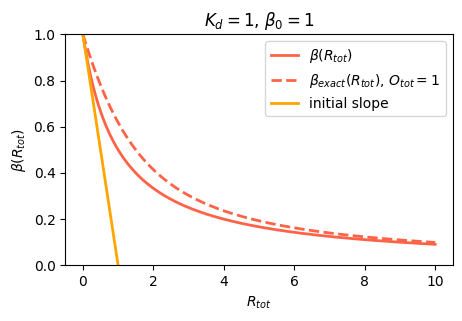

In [12]:
# Build theoretical curves
R_tot = np.linspace(0, 10, 200)
b0 = 1
Kd = 1
beta = b0 / (1 + R_tot / Kd)
init_slope = -R_tot + 1

# exact
O_tot = 1
b = R_tot - O_tot + Kd
beta_exact = b0 * (-b + np.sqrt(b**2 + 4 * Kd * O_tot) )/ (2 * O_tot)

# Build plot
plt.figure(figsize=(5,3))
plt.title(fr'$K_d = {Kd}$, $\beta_0 = {b0}$')
plt.xlabel(r"$R_{tot}$")
plt.ylabel(r"$\beta(R_{tot})$")
plt.plot(R_tot, beta, linewidth=2, color="tomato", label=r"$\beta(R_{tot})$")
plt.plot(R_tot, beta_exact, '--', linewidth=2, color="tomato", label=fr"$\beta_{{exact}}(R_{{tot}})$, $O_{{tot}} = {O_tot}$")
plt.plot(R_tot, init_slope, linewidth=2, color="orange", label="initial slope")
plt.ylim(0,1)
plt.legend()
plt.show()

> **_Question:_** What happens if you keep increasing the number of promoters in the cell? Check it out in the above code. 

## Gene expression can be leaky

As an aside, we note that in real life, many genes never get repressed all the way to zero expression, even when you add a lot of repressor. Instead, there is a baseline, or "basal", expression level that still occurs. A simple way to model this is by adding an additional constant term, $\alpha_0$ to the expression 

\begin{align}
\beta(R_\mathrm{tot}) = \alpha_0 + \beta_0 \frac{O}{O_\mathrm{tot}} = \alpha_0 + \frac{\beta_0}{1+R_\mathrm{tot}/K_\mathrm{d}}.
\end{align}

Given the ubiquitousness of leakiness, it is important to check that circuit behaviors do not depend on the absence of leaky expression.

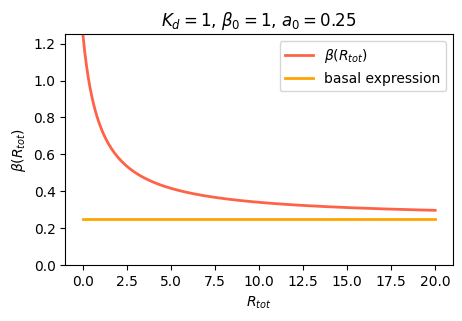

In [13]:
# Build the theoretical curves
R_tot = np.linspace(0, 20, 200)
b0 = 1
Kd = 1
a0 = 0.25
beta = a0 + b0 / (1 + R_tot / Kd)

# Build plot
plt.figure(figsize=(5,3))
plt.title(rf"$K_{{d}} = {Kd}$, $\beta_{{0}} = {b0}$, $a_{{0}} = {a0}$")
plt.xlabel(r"$R_{tot}$")
plt.ylabel(r"$\beta(R_{tot})$")
plt.plot(R_tot, beta,
    linewidth=2,
    color="tomato",
    label=r"$\beta(R_{tot})$")
plt.plot([R_tot[0], R_tot[-1]], [a0, a0],
    linewidth=2,
    color="orange",
    label="basal expression")
plt.ylim(0, beta.max())
plt.legend()
plt.show()

> **__Side note:__** Several extensions of the simple promoter model exist. An example is bursty expressions of genes that is observed in experiments.

## Activation

Genes can be regulated by activators as well as repressors. Treating the case of activation just involves switching the state that is actively expressing from the unbound one to the one bound by the protein (now called an Activator). And, just as the binding of a repressor to DNA can be modulated by small molecule inputs, so too can the binding of the activator be modulated by binding to small molecules. In bacteria, one of many examples is the [arabinose regulation system](https://en.wikipedia.org/wiki/L-arabinose_operon).

<figure style="width: 550px; margin: auto; padding: 20px; background-color:white;">
  <img src="figs/activation.svg" alt="activation by binding to operator">
</figure>

<br>

\begin{align}
\beta(A) = \beta_0 \frac{O_\mathrm{occ}}{O_\mathrm{tot}} = \frac{\beta_0 A/K_\mathrm{d}}{1+A/K_\mathrm{d}}.
\end{align}

Under the simplifying assumption as in the repressor case, this produces the opposite, mirror image response compared to repression, shown below with no leakage.

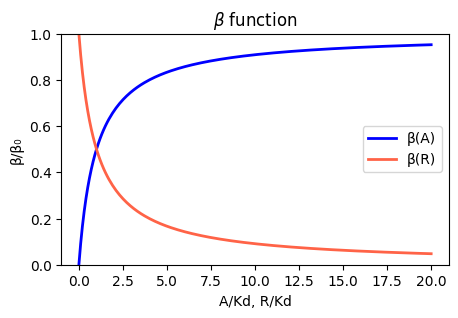

In [14]:
# 4
A = np.linspace(0, 20, 200)
R = np.linspace(0, 20, 200)
beta_A = A / (1 + A)
beta_R = 1 / (1 + R)

# Build plot
plt.figure(figsize=(5,3))
plt.title(r"$\beta$ function")
plt.xlabel("A/Kd, R/Kd")
plt.ylabel("β/β₀")
plt.plot(A, beta_A,
    linewidth=2,
    color="blue",
    label="β(A)")
plt.plot(R, beta_R,
    linewidth=2,
    color="tomato",
    label="β(R)")
plt.ylim(0, 1)
plt.legend()
plt.show()

## Activator vs. Repressor – which to choose?

We have reached a central design question:

> **_Question:_** The cell has at least two different ways to regulate a gene: using an activator or using a repressor. Which should it choose? Which would you choose if you were designing a synthetic circuit? Why? Are they completely equivalent ways to regulate a target gene? Is one better in some or all conditions? How could we know?  

These questions were  posed in a [study by Michael Savageau (PNAS, 1974)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC388476/), who tried to explain the naturally observed usage of activation and repression in bacteria. A different explanation was later developed by [Shinar et al (PNAS 2004)](https://doi.org/10.1073/pnas.0506610103). We end the lecture with this question - try to think about when and why you would use each type of regulation! 



# Further reading

As starting material we highly recommand open courses like:
- The course [Biological Circuit Design](http://be150.caltech.edu/2020/content/index.html) at Caltech by Elowitz and Bois. Our course is derived from this course.
- The course [Introduction to Biological Engineering Design](https://ocw.mit.edu/courses/biological-engineering/20-020-introduction-to-biological-engineering-design-spring-2009/index.htm) at MIT by Kuldell and Endy



---
**License & Attribution**: This page is adapted from material by [Michael Elowitz and Justin Bois](https://biocircuits.github.io/) (© 2021–2025), licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).